In [2]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
X_train_t = torch.tensor(X_train_s)
X_test_t = torch.tensor(X_test_s)

In [4]:

# --- Simple MLP ---
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

In [5]:
# --- Constraint: "Patients with BOTH large worst radius AND high concave points 
#     should have LOW probability of being benign" ---

def constraint_loss(model, X_batch, feature_names, lambda_constraint=1.0):
    """
    Penalize the model when it predicts high P(benign) for patients
    whose 'worst radius' and 'worst concave points' are both above
    the 75th percentile.
    """
    worst_radius_idx = list(feature_names).index('worst radius')
    worst_concave_idx = list(feature_names).index('worst concave points')
    
    # These thresholds are on the standardized scale
    # (roughly: 75th percentile of training data ≈ +0.67 in standard normal)
    radius_high = X_batch[:, worst_radius_idx] > 0.67
    concave_high = X_batch[:, worst_concave_idx] > 0.67
    both_high = radius_high & concave_high
    
    if both_high.sum() == 0:
        return torch.tensor(0.0)
    
    # For these patients, the model should predict LOW P(benign)
    # Penalize predictions that are above 0.3 for this group
    preds = model(X_batch[both_high])
    penalty = torch.relu(preds - 0.3).mean()
    return lambda_constraint * penalty

In [6]:
# --- Training loop with and without constraint ---
def train_model(use_constraint=False, lambda_val=1.0, epochs=150):
    model = SimpleMLP(X_train_s.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    bce = nn.BCELoss()
    
    losses = {'bce': [], 'constraint': [], 'total': []}
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        preds = model(X_train_t)
        loss_bce = bce(preds, y_train_t)
        
        if use_constraint:
            loss_c = constraint_loss(model, X_train_t, data.feature_names, lambda_val)
        else:
            loss_c = torch.tensor(0.0)
        
        total_loss = loss_bce + loss_c
        total_loss.backward()
        optimizer.step()
        
        losses['bce'].append(loss_bce.item())
        losses['constraint'].append(loss_c.item())
        losses['total'].append(total_loss.item())
    
    return model, losses

In [7]:
# Train both versions
model_unconstrained, losses_u = train_model(use_constraint=False)
model_constrained, losses_c = train_model(use_constraint=True, lambda_val=2.0)

# Evaluate
for name, model in [("Unconstrained", model_unconstrained), ("Constrained", model_constrained)]:
    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t) > 0.5).int().numpy()
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds, target_names=data.target_names))

# --- Analyze: Focus specifically on patients in the "both high" region
model_unconstrained.eval()
model_constrained.eval()
with torch.no_grad():
    preds_u = model_unconstrained(X_test_t).numpy()
    preds_c = model_constrained(X_test_t).numpy()

worst_radius_idx = list(data.feature_names).index('worst radius')
worst_concave_idx = list(data.feature_names).index('worst concave points')
high_risk = (X_test_s[:, worst_radius_idx] > 0.67) & (X_test_s[:, worst_concave_idx] > 0.67)

print(f"\nPatients in 'both high' region: {high_risk.sum()}")
print(f"Unconstrained avg P(benign) for this group: {preds_u[high_risk].mean():.3f}")
print(f"Constrained avg P(benign) for this group: {preds_c[high_risk].mean():.3f}")
print(f"Actual benign rate for this group: {y_test[high_risk].mean():.3f}")



=== Unconstrained ===
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.97        43
      benign       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== Constrained ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        43
      benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Patients in 'both high' region: 24
Unconstrained avg P(benign) for this group: 0.000
Constrained avg P(benign) for this group: 0.001
Actual benign rate for this group: 0.000


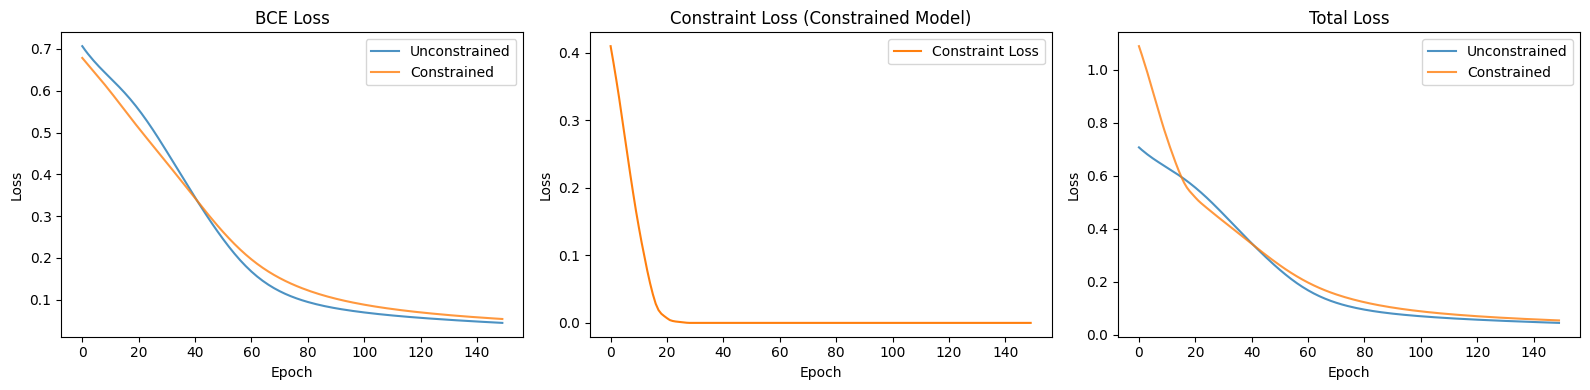

In [8]:
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
# BCE Loss comparison
axes[0].plot(losses_u['bce'], label='Unconstrained', alpha=0.8)
axes[0].plot(losses_c['bce'], label='Constrained', alpha=0.8)
axes[0].set_title('BCE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
 
# Constraint loss (only meaningful for the constrained model)
axes[1].plot(losses_c['constraint'], label='Constraint Loss', color='tab:orange')
axes[1].set_title('Constraint Loss (Constrained Model)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
 
# Total loss comparison
axes[2].plot(losses_u['total'], label='Unconstrained', alpha=0.8)
axes[2].plot(losses_c['total'], label='Constrained', alpha=0.8)
axes[2].set_title('Total Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
 
plt.tight_layout()
plt.show()
 

λ=0.0  |  Accuracy: 0.9825  |  Avg P(benign) high-risk group: 0.0008
λ=0.5  |  Accuracy: 0.9912  |  Avg P(benign) high-risk group: 0.0026
λ=1.0  |  Accuracy: 0.9912  |  Avg P(benign) high-risk group: 0.0022
λ=2.0  |  Accuracy: 0.9737  |  Avg P(benign) high-risk group: 0.0010
λ=5.0  |  Accuracy: 0.9825  |  Avg P(benign) high-risk group: 0.0098


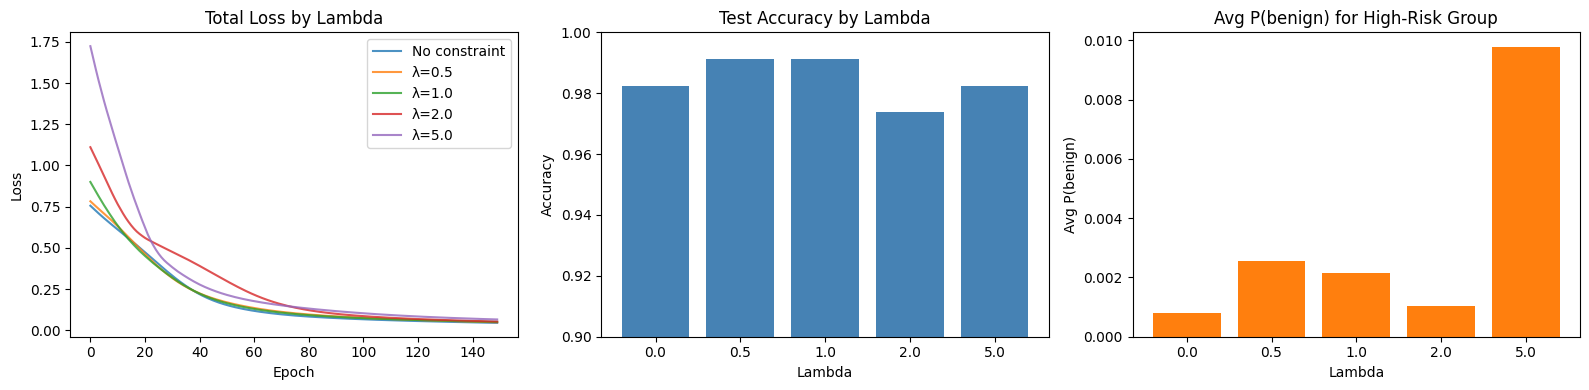

In [9]:
import matplotlib.pyplot as plt

lambda_values = [0.0, 0.5, 1.0, 2.0, 5.0]
results = {}

for lam in lambda_values:
    use_c = lam > 0
    model, losses = train_model(use_constraint=use_c, lambda_val=lam, epochs=150)
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).numpy()
        acc = ((preds > 0.5).astype(int) == y_test).mean()
        avg_benign_high_risk = preds[high_risk].mean()
    results[lam] = {
        'model': model,
        'losses': losses,
        'accuracy': acc,
        'avg_p_benign_high_risk': avg_benign_high_risk,
        'total_losses': losses['total']
    }
    print(f"λ={lam:.1f}  |  Accuracy: {acc:.4f}  |  Avg P(benign) high-risk group: {avg_benign_high_risk:.4f}")

# --- Plot 1: Total loss curves across lambda values ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for lam, res in results.items():
    label = f'λ={lam}' if lam > 0 else 'No constraint'
    axes[0].plot(res['total_losses'], label=label, alpha=0.8)
axes[0].set_title('Total Loss by Lambda')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# --- Plot 2: Final accuracy vs lambda ---
lambdas = list(results.keys())
accs = [results[l]['accuracy'] for l in lambdas]
axes[1].bar([str(l) for l in lambdas], accs, color='steelblue')
axes[1].set_title('Test Accuracy by Lambda')
axes[1].set_xlabel('Lambda')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.9, 1.0)

# --- Plot 3: Avg P(benign) for high-risk group vs lambda ---
avg_ps = [results[l]['avg_p_benign_high_risk'] for l in lambdas]
axes[2].bar([str(l) for l in lambdas], avg_ps, color='tab:orange')
axes[2].set_title('Avg P(benign) for High-Risk Group')
axes[2].set_xlabel('Lambda')
axes[2].set_ylabel('Avg P(benign)')

plt.tight_layout()
plt.show()

In [10]:
# --- Output-Structure Constraint: Ordinal Consistency ---
# Reframe Wisconsin as a 3-class ordinal problem: Low / Medium / High risk
# Then enforce that the model's output probabilities respect the ordering

import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y_binary = data.target  # 1=benign, 0=malignant

# Create a 3-class ordinal target based on "worst radius" as a risk proxy:
# Low risk: benign AND worst radius in bottom tertile
# Medium risk: benign AND worst radius in top two tertiles, OR malignant AND bottom tertile
# High risk: malignant AND worst radius in top two tertiles
worst_radius = X[:, list(data.feature_names).index('worst radius')]
radius_threshold = np.percentile(worst_radius, 33)

y_ordinal = np.where(
    (y_binary == 1) & (worst_radius <= radius_threshold), 0,  # low risk
    np.where(
        (y_binary == 0) & (worst_radius > radius_threshold), 2,  # high risk
        1  # medium risk
    )
)

X_train, X_test, y_train, y_test = train_test_split(X, y_ordinal, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_test_s = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

# 3-class MLP
class OrdinalMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 3),  # 3 classes: low, medium, high
        )
    def forward(self, x):
        return self.net(x)

# --- The output-structure constraint ---
# Ordinal consistency: if the model's argmax is "low risk" (class 0),
# then P(low) should be > P(medium) > P(high).

def ordinal_consistency_loss(logits, lambda_ordinal=1.0):
    """
    Penalize cases where the model's softmax probabilities violate ordinal ordering.
    For a 3-class ordinal problem (low < medium < high risk):
    - The cumulative probability P(risk >= k) should decrease as k increases
    - Equivalently: penalize when P(class j) > P(class i) for j > i, 
      among classes that should both be "unlikely" given the prediction
    """
    probs = torch.softmax(logits, dim=1)  # shape: (batch, 3)
    
    # Penalize when P(high) > P(medium) for samples predicted as low risk
    # AND when P(low) > P(medium) for samples predicted as high risk
    
    predicted = torch.argmax(probs, dim=1)
    penalty = torch.tensor(0.0)
    
    # For samples predicted as low risk (class 0):
    # P(high) should be < P(medium) should be < P(low)
    low_mask = predicted == 0
    if low_mask.sum() > 0:
        p = probs[low_mask]
        # Penalize if P(high) > P(medium) — the ordering is "backwards"
        penalty = penalty + torch.relu(p[:, 2] - p[:, 1]).mean()
    
    # For samples predicted as high risk (class 2):
    # P(low) should be < P(medium) should be < P(high)
    high_mask = predicted == 2
    if high_mask.sum() > 0:
        p = probs[high_mask]
        # Penalize if P(low) > P(medium) — the ordering is "backwards"
        penalty = penalty + torch.relu(p[:, 0] - p[:, 1]).mean()
    
    return lambda_ordinal * penalty

# --- Train with and without ordinal constraint ---
def train_ordinal_model(use_constraint=False, epochs=150):
    model = OrdinalMLP(X_train_s.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    ce_loss = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_s)
        loss = ce_loss(logits, y_train_t)
        if use_constraint:
            loss = loss + ordinal_consistency_loss(logits, lambda_ordinal=1.0)
        loss.backward()
        optimizer.step()
    return model

model_uc = train_ordinal_model(use_constraint=False)
model_c = train_ordinal_model(use_constraint=True)

# Compare: do the constrained model's probability distributions look "cleaner"?
for name, model in [("Unconstrained", model_uc), ("Constrained", model_c)]:
    model.eval()
    with torch.no_grad():
        logits = model(X_test_s)
        probs = torch.softmax(logits, dim=1).numpy()
        preds = np.argmax(probs, axis=1)
    
    # Check ordinal violations: how often is P(high) > P(medium) when predicted low?
    low_pred = preds == 0
    if low_pred.sum() > 0:
        violations = (probs[low_pred, 2] > probs[low_pred, 1]).mean()
        print(f"{name}: Among low-risk predictions, "
              f"{violations:.1%} have P(high) > P(medium) [ordinal violation]")
    
    acc = (preds == y_test).mean()
    print(f"{name}: Accuracy = {acc:.3f}\n")

Unconstrained: Among low-risk predictions, 0.0% have P(high) > P(medium) [ordinal violation]
Unconstrained: Accuracy = 0.921

Constrained: Among low-risk predictions, 0.0% have P(high) > P(medium) [ordinal violation]
Constrained: Accuracy = 0.921



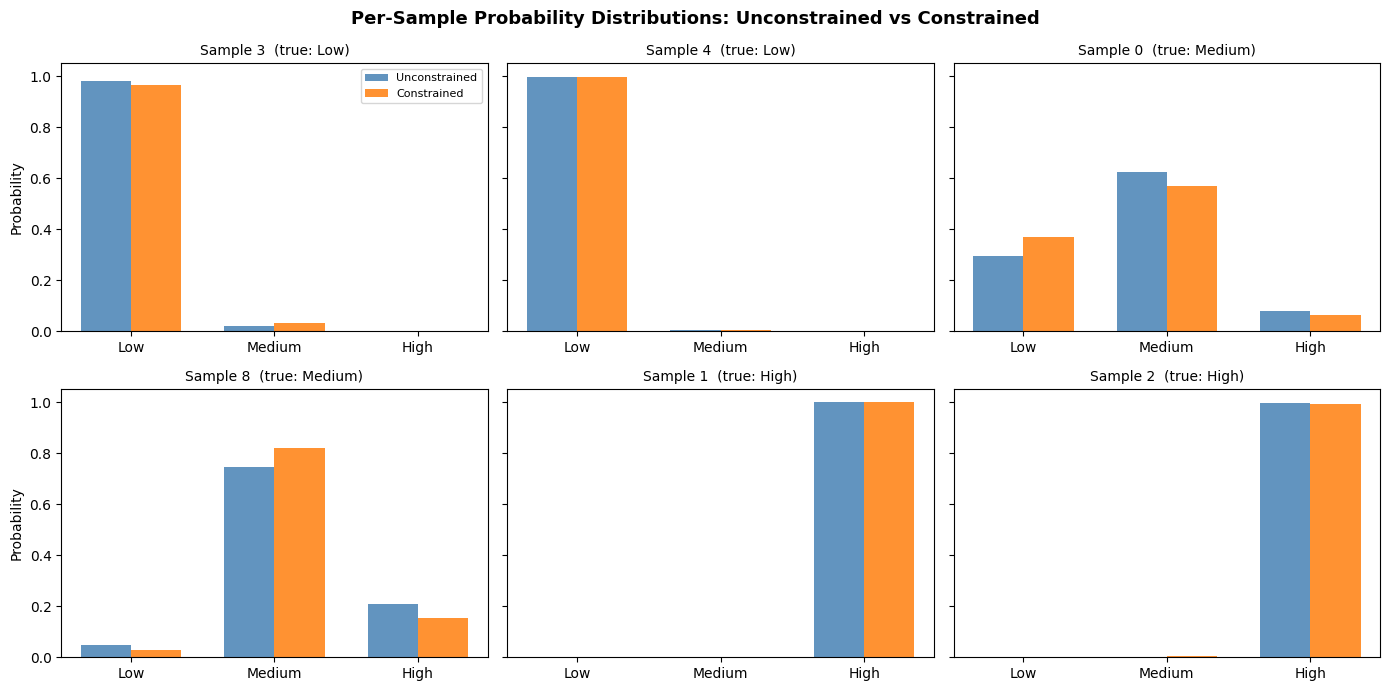

In [11]:
# Visualize probability distributions for a few test samples from each model

import matplotlib.pyplot as plt
import numpy as np
import torch

# Get predictions from both models
model_uc.eval()
model_c.eval()
with torch.no_grad():
    logits_uc = model_uc(X_test_s)
    logits_c  = model_c(X_test_s)
    probs_uc  = torch.softmax(logits_uc, dim=1).numpy()
    probs_c   = torch.softmax(logits_c,  dim=1).numpy()

preds_uc = np.argmax(probs_uc, axis=1)
preds_c  = np.argmax(probs_c,  axis=1)

# Pick a diverse set of samples: 2 predicted low, 2 medium, 2 high (from unconstrained)
sample_indices = []
for cls in [0, 1, 2]:
    candidates = np.where(preds_uc == cls)[0]
    chosen = candidates[:2] if len(candidates) >= 2 else candidates
    sample_indices.extend(chosen)

class_labels = ["Low", "Medium", "High"]
true_label_map = {0: "Low", 1: "Medium", 2: "High"}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)

for i, idx in enumerate(sample_indices[:6]):
    row = i // 3
    col = i % 3
    ax = axes[row, col]

    x_pos = np.arange(3)
    width = 0.35

    ax.bar(x_pos - width/2, probs_uc[idx], width, label="Unconstrained",
           color="steelblue", alpha=0.85)
    ax.bar(x_pos + width/2, probs_c[idx],  width, label="Constrained",
           color="tab:orange", alpha=0.85)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(class_labels)
    ax.set_title(f"Sample {idx}  (true: {true_label_map[y_test[idx]]})",
                 fontsize=10)
    ax.set_ylim(0, 1.05)

    if col == 0:
        ax.set_ylabel("Probability")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Per-Sample Probability Distributions: Unconstrained vs Constrained",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

=== Sharpness (Entropy) ===
  Unconstrained avg entropy: 0.2016
  Constrained   avg entropy: 0.2310
  → Unconstrained is sharper (lower entropy)

=== Ordinal Consistency ===
  Unconstrained violations: 0/114  (0.0%)
  Constrained   violations: 0/114   (0.0%)

=== Near-Violation Margin (higher = more safely ordered) ===
  Unconstrained avg margin: 0.0575
  Constrained   avg margin: 0.0654


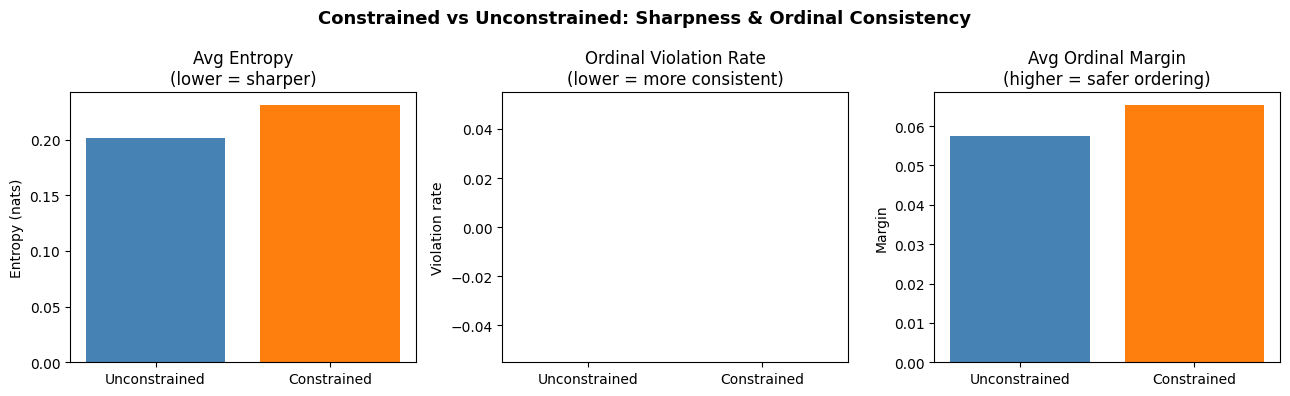

In [12]:

# Does the constrained model produce "sharper" or more ordinal-consistent predictions?

# --- Metric 1: Entropy (lower = sharper) ---
def avg_entropy(probs):
    """Average Shannon entropy across all samples (in nats)."""
    # Clip to avoid log(0)
    p = np.clip(probs, 1e-12, 1.0)
    return -np.mean(np.sum(p * np.log(p), axis=1))

ent_uc = avg_entropy(probs_uc)
ent_c  = avg_entropy(probs_c)

print("=== Sharpness (Entropy) ===")
print(f"  Unconstrained avg entropy: {ent_uc:.4f}")
print(f"  Constrained   avg entropy: {ent_c:.4f}")
print(f"  → {'Constrained' if ent_c < ent_uc else 'Unconstrained'} is sharper "
      f"(lower entropy)\n")

# --- Metric 2: Ordinal violation rate (full check) ---
def ordinal_violations(probs, preds):
    """
    Count samples where the probability ordering violates ordinal structure.
    For predicted class 0 (low):  violation if P(high) > P(medium)
    For predicted class 2 (high): violation if P(low)  > P(medium)
    For predicted class 1 (mid):  violation if P(low) > P(mid) or P(high) > P(mid)
    """
    n = len(preds)
    violations = 0
    for i in range(n):
        p = probs[i]
        if preds[i] == 0:    # predicted low
            if p[2] > p[1]:  # P(high) > P(medium)
                violations += 1
        elif preds[i] == 2:  # predicted high
            if p[0] > p[1]:  # P(low) > P(medium)
                violations += 1
        else:                # predicted medium
            if p[0] > p[1] or p[2] > p[1]:  # either tail > center
                violations += 1
    return violations, violations / n

v_uc, rate_uc = ordinal_violations(probs_uc, preds_uc)
v_c,  rate_c  = ordinal_violations(probs_c,  preds_c)

print("=== Ordinal Consistency ===")
print(f"  Unconstrained violations: {v_uc}/{len(preds_uc)}  ({rate_uc:.1%})")
print(f"  Constrained   violations: {v_c}/{len(preds_c)}   ({rate_c:.1%})")

# --- Metric 3: "Near-violation margin" ---
# Even if there are 0 violations, how CLOSE is the model to violating?
# For predicted-low samples: margin = P(medium) - P(high)  (bigger = safer)
def avg_margins(probs, preds):
    margins = []
    for i in range(len(preds)):
        p = probs[i]
        if preds[i] == 0:
            margins.append(p[1] - p[2])   # P(med) - P(high)
        elif preds[i] == 2:
            margins.append(p[1] - p[0])   # P(med) - P(low)
    return np.mean(margins) if margins else float('nan')

margin_uc = avg_margins(probs_uc, preds_uc)
margin_c  = avg_margins(probs_c,  preds_c)

print(f"\n=== Near-Violation Margin (higher = more safely ordered) ===")
print(f"  Unconstrained avg margin: {margin_uc:.4f}")
print(f"  Constrained   avg margin: {margin_c:.4f}")

# --- Summary bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Entropy comparison
axes[0].bar(["Unconstrained", "Constrained"], [ent_uc, ent_c],
            color=["steelblue", "tab:orange"])
axes[0].set_title("Avg Entropy\n(lower = sharper)")
axes[0].set_ylabel("Entropy (nats)")

# Violation rate
axes[1].bar(["Unconstrained", "Constrained"], [rate_uc, rate_c],
            color=["steelblue", "tab:orange"])
axes[1].set_title("Ordinal Violation Rate\n(lower = more consistent)")
axes[1].set_ylabel("Violation rate")

# Margin
axes[2].bar(["Unconstrained", "Constrained"], [margin_uc, margin_c],
            color=["steelblue", "tab:orange"])
axes[2].set_title("Avg Ordinal Margin\n(higher = safer ordering)")
axes[2].set_ylabel("Margin")

plt.suptitle("Constrained vs Unconstrained: Sharpness & Ordinal Consistency",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()